
---

## **Machine Learnig**
##**Predicting Employee Turnover Complete Guide Analysis**
---


**Dana Hmeed**






### **The Problem**:
* One of the most common problems at work is turnover.
* Employee turnover is costly, impacts productivity, affects team, and increases recruitment expenses.
*   Replacing a high-level employee can cost multiple of that...






### **Project Objectives**

*  Analyze employee data for patterns related to turnover
* To perform clustering to find any meaningful patterns of employee traits.
* Train ML models to predict future turnover
* Compare model performance
* Recommend retention strategies for high-risk employee groups



### **Data Import and Preprocessing**

In [ ]:
import pandas as pd

df = pd.read_csv('/content/HR_comma_sep.csv')
df.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
#Rename 'sales' column to department
df=df.rename(columns = {'sales':'department'})


### **Exploring the Data**

In [ ]:
#dimesnsions
df.shape

(14999, 10)

In [ ]:
# Check the type of each feature
df.dtypes


,0
satisfaction_level,float64
last_evaluation,float64
number_project,int64
average_montly_hours,int64
time_spend_company,int64
Work_accident,int64
left,int64
promotion_last_5years,int64
department,object
salary,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [ ]:
# Display the statistical overview of the employees
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


 ### **Step1: Perform data quality checks by checking for missing values, if any.**

In [ ]:
#Check for Missing Values and count the sum
df.isnull().sum()

,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
department,0
salary,0


In [ ]:
#find out the number of employees who left the company and those who didn’t
df['left'].value_counts()


,count
left,
0,11428
1,3571


### **Step2 : Heatmap – Correlation between numerical features**

**Summary**:
Heatmap is one of the EDA techniques used to visualize the relationship between variables. It helps identify which features is strongly correlated and have a real impact on the analysis and model building.
* From the heatmap, there is a positive(+) correlation between projectCount, averageMonthlyHours, and evaluation. Which could mean that the employees who spent more hours and did more projects were evaluated highly.

* For the negative(-) relationships, turnover and satisfaction are highly correlated. I'm assuming that people tend to leave a company more when they are less satisfied.

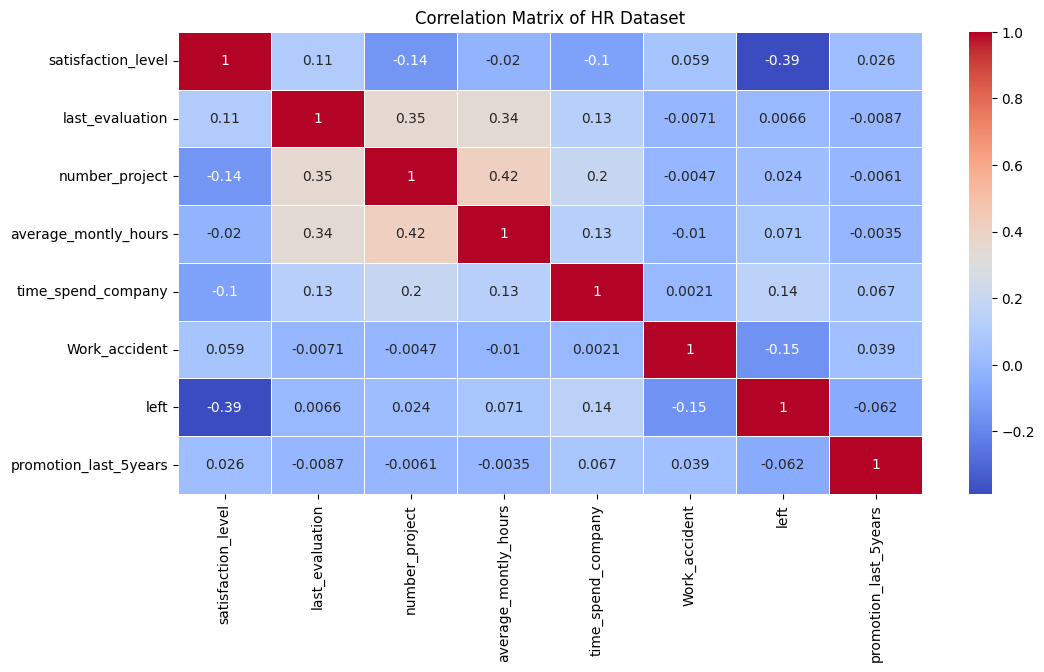

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,6))
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix of HR Dataset")
plt.show()


### **Step2: Distribution Plots (Satisfaction, Evaluation, Hours)**

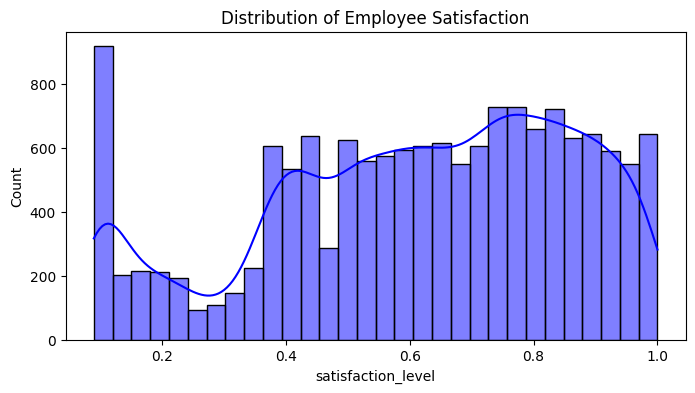

In [ ]:
# Employee Satisfaction
plt.figure(figsize=(8,4))
sns.histplot(df['satisfaction_level'], kde=True, color='blue')
plt.title("Distribution of Employee Satisfaction")
plt.show()


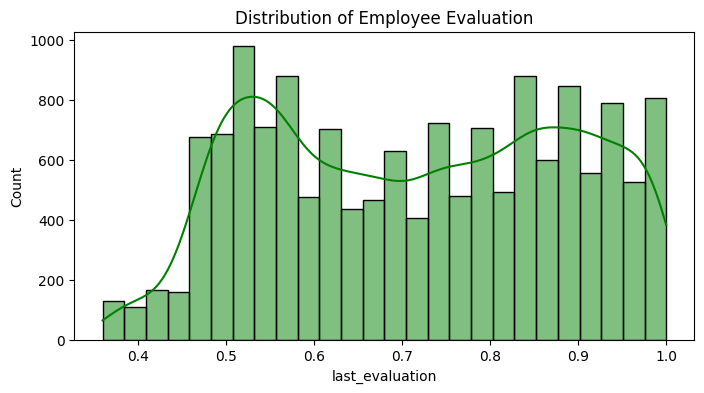

In [ ]:
# Employee Evaluation
plt.figure(figsize=(8,4))
sns.histplot(df['last_evaluation'], kde=True, color='green')
plt.title("Distribution of Employee Evaluation")
plt.show()


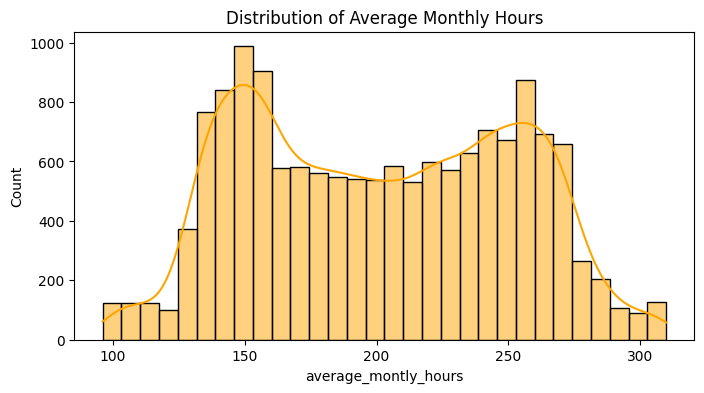

In [ ]:
# Employee Monthly Hours
plt.figure(figsize=(8,4))
sns.histplot(df['average_montly_hours'], kde=True, color='orange')
plt.title("Distribution of Average Monthly Hours")
plt.show()


### **Step 3: Bar Plot – Number of Projects vs Left**

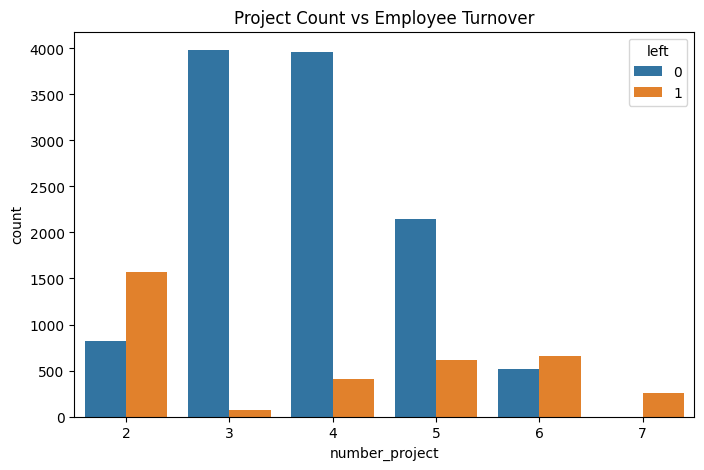

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='number_project', hue='left', data=df)
plt.title("Project Count vs Employee Turnover")
plt.show()


Inferences from the Bar Plot

* Employees with 2 projects show a high turnover.
This indicates lack of challenge, and low engagement.

* Employees with 6 or 7 projects also show high turnover.
This points to overload, and excessive workload.

* Employees with 3 or 5 projects are the most stable.
These counts represent a healthy workload where most employees stay.

* Overall, both underwork and overwork increase the likelihood of leaving, while a balanced number of projects reduces turnover.
Decision:
Maintain employees at 3–5 concurrent projects to balance productivity and satisfaction.



---



### **Step 3.1: Unsupervised Clustering of Employees Who Left**

Purpose of this step
Before building predictive models, it is important to understand patterns among employees who actually left the company.
Clustering helps HR identify different behavioral groups based on satisfaction and evaluation scores, even without using the target variable.

This is unsupervised learning, meaning:

The algorithm does not use the “left” label for training

It discovers natural patterns inside the data on its own

 **Why cluster employees who left?**

Clustering helps answer questions like:

* Are there groups of high performers who still leave?
* Are low-satisfaction employees leaving for similar reasons?
* Do evaluation and satisfaction interact in predictable ways?

In [ ]:
# Filter only employees who left the company
left_df = df[df['left'] == 1]
left_df.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### **Step 3.2: Select the two numerical columns for clustering**

In [ ]:
X = left_df[['satisfaction_level', 'last_evaluation']]


**Normalize the data K-means works better when features are scaled.**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


**Apply K-means clustering into 3 clusters**

Apply K-Means with 3 clusters

We set k = 3 because:

HR typically works with “high”, “medium”, and “low”-risk groups

The dataset visually supports 3 natural behavioral segments

It keeps interpretation simple and actionable

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

left_df['cluster'] = clusters


/tmp/ipython-input-706150814.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  left_df['cluster'] = clusters


### **Step3.3: Visualize the clusters**

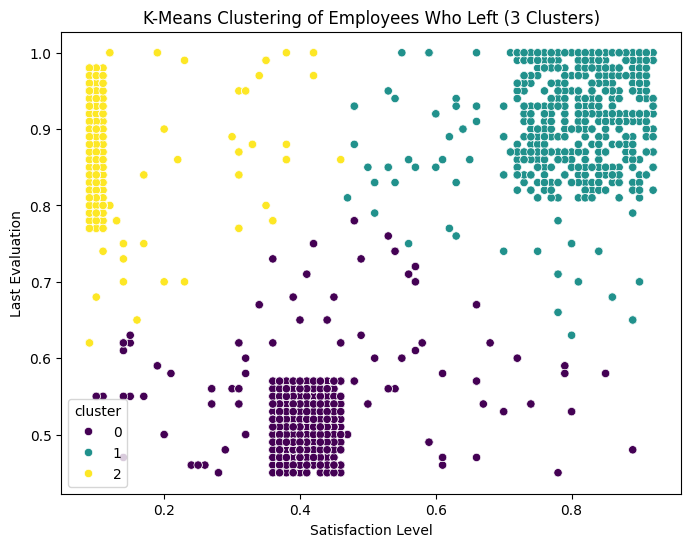

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=left_df['satisfaction_level'],
    y=left_df['last_evaluation'],
    hue=left_df['cluster'],
    palette='viridis'
)
plt.title("K-Means Clustering of Employees Who Left (3 Clusters)")
plt.xlabel("Satisfaction Level")
plt.ylabel("Last Evaluation")
plt.show()


### **Step 3.3: Interpretation**

Cluster 0 – Low Satisfaction, Medium Evaluation (purple)

Employees are not satisfied and show average performance.
They appear disengaged and disconnected from their work, which makes them likely to leave due to lack of support or motivation.

Cluster 1 – High Satisfaction, High Evaluation (blue)

Employees are high performers and highly satisfied.
They usually leave for career advancement or better opportunities, not because of unhappiness. They are ambitious and growth-oriented.

Cluster 2 – Very Low Satisfaction, Very High Evaluation (yellow)

Employees show excellent performance but very low satisfaction.
This is the classic burnout group: overworked, undervalued, and stressed.
They are at the highest risk of sudden turnover.

### **Step 4 – Preprocessing + SMOTE for class imbalance.**
**Step 4.1: Separate categorical + numeric columns**



In [ ]:
# Separate categorical and numeric
categorical_cols = ['department', 'salary']
numeric_cols = df.drop(columns=categorical_cols).columns

df_numeric = df[numeric_cols]
df_categorical = df[categorical_cols]


**Applying get_dummies() to the categorical variables so the model can understand them.**

In [ ]:
df_categorical_encoded = pd.get_dummies(df_categorical, drop_first=True)


**Combine numeric + encoded categorical**

In [ ]:
df_final = pd.concat([df_numeric, df_categorical_encoded], axis=1)
df_final.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False


Define X and y (features + target)

In [ ]:
X = df_final.drop(columns=['left'])
y = df_final['left']


### **Step 4.2: Stratified Train-Test Split (80/20) with random_state=123**

We divide the dataset into two parts:

80% for training the model

20% for testing the model

But we do it using **stratification**, which means:

The proportion of employees who left and employees who stayed is preserved in both the training and testing sets.

This avoids bias.
Without stratification, the test set might accidentally contain mostly “stayed” employees, making evaluation unfair.

**random_state=123 simply ensures you get the same split every time.**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=123
)


### **Step 4.3: Apply SMOTE to Training Set Only**

**SMOTE** creates new, synthetic examples of the minority class instead of just copying rows.
This balances the data so the model can learn fairly from both classes( handle class imbalance).

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=123)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)


In [ ]:
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())


Before SMOTE: left
0    9142
1    2857
Name: count, dtype: int64
After SMOTE: left
0    9142
1    9142
Name: count, dtype: int64


### **Step 5 – Perform 5-fold cross-validation model training and evaluate performance.**

We split the training data into 5 equal parts (folds).

The model is trained 5 times.

Each time:

- 4 folds are used for training

- 1 fold is used for validation

- In the end, we average the results.

Why do we use it?

* To make sure the model is not lucky by chance

* To check that it works well on different data

* To reduce overfitting


Why these algorithms?

* Logistic Regression provides a baseline and interpretable model.

* Random Forest handles nonlinear relationships and prevents overfitting using multiple trees.

* Gradient Boosting builds models sequentially and frequently outperforms RF on structured HR data.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


### **5.1 Logistic Regression with 5-Fold Cross Validation**

use Logistic Regression because:

1. The problem is binary classification
0 → Stay
1 → Leave

2. It gives probability outputs HR needs probability scores (like 0.87 = high risk).

In [ ]:
# Cross Validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# Logistic Regression
log_model = LogisticRegression(max_iter=1500)
y_pred_log = cross_val_predict(log_model, X_train_smote, y_train_smote, cv=cv)

print("Logistic Regression Classification Report:")
print(classification_report(y_train_smote, y_pred_log))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.77      0.79      9142
           1       0.78      0.82      0.80      9142

    accuracy                           0.80     18284
   macro avg       0.80      0.80      0.80     18284
weighted avg       0.80      0.80      0.80     18284



### **5.2 Random Forest Classifier with 5-Fold CV**

Random Forest is an ensemble learning method that builds multiple decision trees using random samples and features.
The final prediction is made using majority voting, which improves accuracy and reduces overfitting.
RF detects patterns Logistic Regression cannot.
Captures complex and nonlinear relationships.


In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=123)
y_pred_rf = cross_val_predict(rf_model, X_train_smote, y_train_smote, cv=cv)

print("Random Forest Classification Report:")
print(classification_report(y_train_smote, y_pred_rf))


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      9142
           1       0.99      0.97      0.98      9142

    accuracy                           0.98     18284
   macro avg       0.98      0.98      0.98     18284
weighted avg       0.98      0.98      0.98     18284



### **5.3 Gradient Boosting Classifier with 5-Fold CV**
Gradient Boosting was used because it builds models sequentially, where each new model learns from the errors of the previous ones. This allows the algorithm to capture complex patterns in employee behavior and results in higher predictive performance for employee turnover.

Gradient Boosting is a powerful ensemble method that builds trees sequentially, where each new tree focuses on fixing the errors made by the previous ones.

In [ ]:
gb_model = GradientBoostingClassifier(random_state=123)
y_pred_gb = cross_val_predict(gb_model, X_train_smote, y_train_smote, cv=cv)

print("Gradient Boosting Classification Report:")
print(classification_report(y_train_smote, y_pred_gb))


Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      9142
           1       0.98      0.95      0.96      9142

    accuracy                           0.96     18284
   macro avg       0.96      0.96      0.96     18284
weighted avg       0.96      0.96      0.96     18284



### **Step 6 – Compare Models Using ROC/AUC + Confusion Matrices**

To judge which model performs best in reality we use two main evaluation tools:

ROC Curve & AUC Score

Confusion Matrix

In [ ]:
log_model.fit(X_train_smote, y_train_smote)
rf_model.fit(X_train_smote, y_train_smote)
gb_model.fit(X_train_smote, y_train_smote)


GradientBoostingClassifier(random_state=123)

**ROC Curve**

The ROC curve shows how well a model separates the two classes (Left vs Stayed) at different probability thresholds.

X-axis → False Positive Rate (mistakenly saying “will leave”)

Y-axis → True Positive Rate (correctly identifying those who leave)

**AUC Score (Area Under Curve)**

AUC is a single number that summarizes the entire ROC curve.

* AUC = 0.5 → useless model (same as guessing)

* AUC between 0.7–0.8 → fair

* AUC between 0.8–0.9 → strong

* AUC > 0.9 → excellent

Why we use AUC

Because accuracy becomes unreliable when classes are imbalanced.
AUC ignores class imbalance and focuses on how well the model ranks risky employees.

What this step tells us

Which model is best at distinguishing employees who leave vs stay, regardless of threshol

### **6.1 ROC / AUC and Plot Curves**

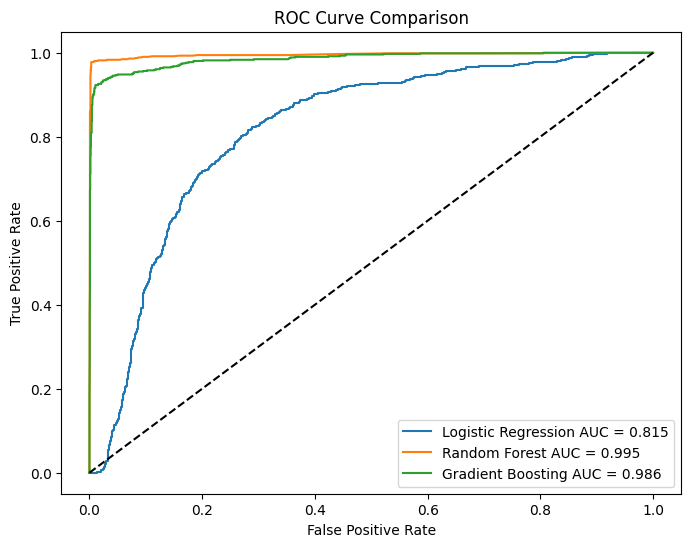

In [ ]:
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} AUC = {auc:.3f}")

plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


### **6.2 Confusion Matrix for Each Model**

A confusion matrix shows how well the model separates the two classes:

Employees who stayed

Employees who left

It breaks predictions into four simple outcomes:

* TP (True Positive): Model correctly predicts an employee will leave

* FP (False Positive): Model predicts leave but the employee stays

* TN (True Negative): Model correctly predicts an employee will stay

* FN (False Negative): Model predicts stay but the employee actually leaves

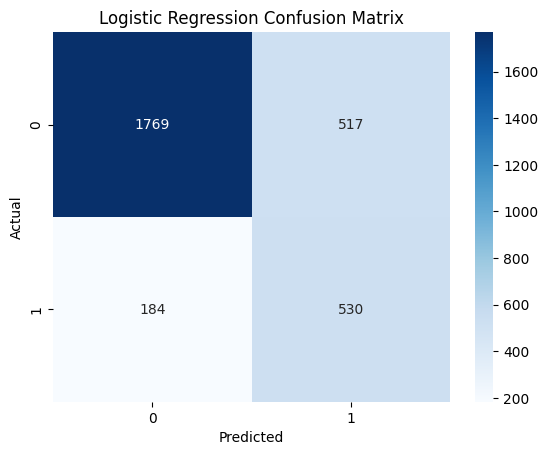

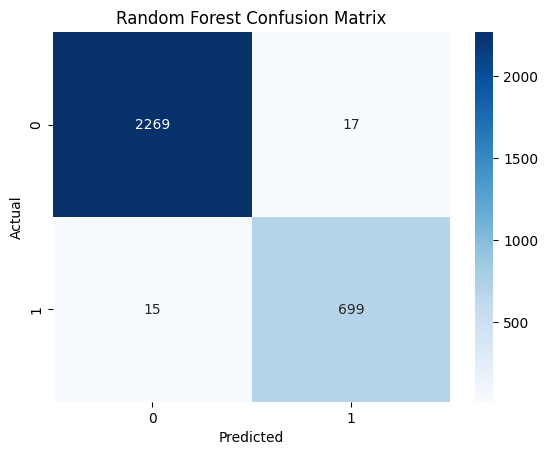

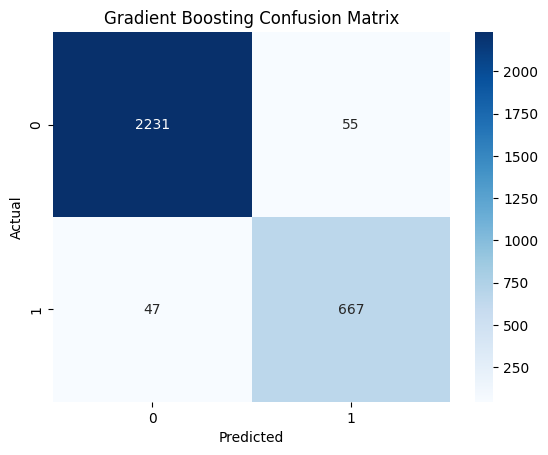

In [ ]:
def plot_conf(model, title):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_conf(log_model, "Logistic Regression Confusion Matrix")
plot_conf(rf_model, "Random Forest Confusion Matrix")
plot_conf(gb_model, "Gradient Boosting Confusion Matrix")


### **6.3 Which Metric Matters: Precision or Recall?**

In employee turnover prediction, RECALL is more important than precision.

Because:

If we FAIL to detect an employee who is likely to resign (false negative), the company loses talent.

Missing them means lost productivity, replacement cost, recruitment cost, training cost.

Interpretation to include in report:

Recall is prioritized over precision because the HR department must avoid failing to identify employees who intend to leave. Catching them early allows implementing retention strategies such as salary correction, workload adjustments, or engagement programs.

### **Step 7 – Retention Strategy Based on Predictions**

### **7.1 Predict Probability for Test Data Using Best Model**

Best model: Random Forest

Best AUC score: 0.995

Best confusion matrix: Random Forest (almost perfect classification)




**Best model must be the one that**:

has the highest Recall for class 1

has the highest Precision

has the lowest false negatives (FN)

best confusion matrix

best AUC

In [ ]:
# Predict probability of turnover using the best model (Random Forest)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Store results
test_results = X_test.copy()
test_results['Turnover_Probability'] = y_prob

test_results.head()


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_low,salary_medium,Turnover_Probability
10627,0.98,0.77,3,191,2,0,0,False,False,False,False,False,False,True,False,False,False,True,0.000
2703,0.76,0.93,3,271,5,0,0,False,False,True,False,False,False,False,False,False,True,False,0.645
6059,0.70,0.93,3,185,4,0,0,False,True,False,False,False,False,False,False,False,False,True,0.045
3258,0.48,0.61,3,223,3,1,0,False,False,False,False,False,False,False,True,False,False,True,0.005
4565,0.57,0.90,3,144,2,0,0,False,False,False,False,False,False,False,False,False,False,True,0.005


### **Step7.2 Categorize Risk Zones**

In [ ]:
def categorize(p):
    if p < 0.2:
        return "Safe Zone (Green)"
    elif p < 0.6:
        return "Low Risk (Yellow)"
    elif p < 0.9:
        return "Medium Risk (Orange)"
    else:
        return "High Risk (Red)"

test_results['Risk_Category'] = test_results['Turnover_Probability'].apply(categorize)
test_results.head(10)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,salary_low,salary_medium,Turnover_Probability,Risk_Category
10627,0.98,0.77,3,191,2,0,0,False,False,False,False,False,False,True,False,False,False,True,0.000,Safe Zone (Green)
2703,0.76,0.93,3,271,5,0,0,False,False,True,False,False,False,False,False,False,True,False,0.645,Medium Risk (Orange)
6059,0.70,0.93,3,185,4,0,0,False,True,False,False,False,False,False,False,False,False,True,0.045,Safe Zone (Green)
3258,0.48,0.61,3,223,3,1,0,False,False,False,False,False,False,False,True,False,False,True,0.005,Safe Zone (Green)
4565,0.57,0.90,3,144,2,0,0,False,False,False,False,False,False,False,False,False,False,True,0.005,Safe Zone (Green)
4991,0.79,0.82,3,98,3,1,0,False,False,True,False,False,False,False,False,False,True,False,0.015,Safe Zone (Green)
13976,0.92,0.64,4,190,10,1,0,False,False,False,True,False,False,False,False,False,True,False,0.000,Safe Zone (Green)
9427,0.98,0.54,4,178,3,0,0,False,False,False,False,False,False,False,False,True,True,False,0.000,Safe Zone (Green)
7173,1.00,0.61,5,264,3,0,0,True,False,False,False,False,False,False,False,False,False,True,0.005,Safe Zone (Green)
13412,0.53,0.64,3,143,2,0,0,False,False,False,False,False,False,True,False,False,True,False,0.010,Safe Zone (Green)


### **Retention Strategies**

**Safe Zone (Green): Probability < 20 percent**

These employees show very low risk of leaving. They are satisfied, stable, and engaged.**Strategy**: Maintain good conditions, keep engagement steady.

**Low-Risk Zone (Yellow): 20–60 percent**

Employees are mostly stable but show early warning signs (moderate workload pressure).**Strategy**: Light monitoring, regular check-ins, small development opportunities.

**Medium-Risk Zone (Orange): 60–90 percent**

Employees are unhappy, overloaded, or under-recognized They may leave.**Strategy**: Early intervention, adjust workload, offer growth paths, address concerns quickly.

**High-Risk Zone (Red): Probability > 90 percent**

These employees are almost certain to leave.**Strategy**: Immediate retention efforts, address workload/stress, offer incentives or role adjustments.

### **Final Conclusion**

This analysis demonstrates how machine learning can effectively predict employee turnover and support data-driven HR decisions. Using Random Forest as the strongest model (AUC 0.995), accurately identify at-risk employees and categorize them into meaningful risk zones. The clustering analysis highlights distinct behavioral patterns among employees who leave, including burnout, disengagement, and high-performer mobility. Combined with probability-based risk scoring, the organization can implement targeted retention strategies that focus on improving satisfaction, reducing overload, and strengthening career development. By integrating these insights into HR planning, companies can proactively reduce turnover, protect high-performing talent, and build a healthier, more resilient workforce.